In [1]:
# 8.6 Q1 - Quadratic Distribution with SVM

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv('datasets/quadratic_sample.csv')
print("Shape:", df.shape)
print(df.head())
print()
print("Class distribution:")
print(df['label'].value_counts())

Shape: (200, 3)
      x1     x2  label
0  1.644  1.664      0
1 -0.367  2.831      1
2  2.152  0.004      0
3  1.184 -2.137      0
4 -2.435 -2.916      0

Class distribution:
label
0    145
1     55
Name: count, dtype: int64


In [4]:
X = df[['x1', 'x2']].values
y = df['label'].values
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (200, 2) y shape: (200,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)
print("Standardised.")

Standardised.


In [6]:
# Train SVM with RBF kernel

In [7]:
model = SVC(kernel='rbf', random_state=0)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
print("Accuracy (RBF):", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy (RBF): 0.95

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        44
           1       0.93      0.88      0.90        16

    accuracy                           0.95        60
   macro avg       0.94      0.93      0.93        60
weighted avg       0.95      0.95      0.95        60



In [8]:
# Compare with Linear kernel

In [9]:
model_lin = SVC(kernel='linear', random_state=0)
model_lin.fit(X_train_s, y_train)
y_pred_lin = model_lin.predict(X_test_s)
print("Accuracy (Linear):", accuracy_score(y_test, y_pred_lin))
print("(Linear kernel cannot capture quadratic boundary well)")

Accuracy (Linear): 0.7833333333333333
(Linear kernel cannot capture quadratic boundary well)


In [10]:
# Decision Boundary

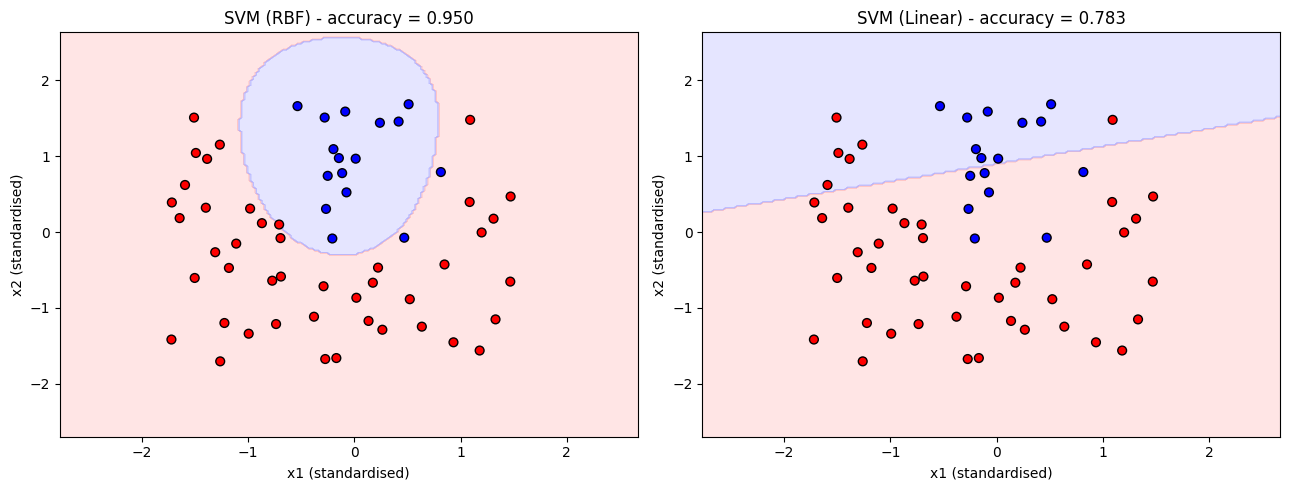

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, kernel, name in zip(axes, ['rbf', 'linear'], ['RBF', 'Linear']):
    m = SVC(kernel=kernel, random_state=0).fit(X_train_s, y_train)
    x_min, x_max = X_train_s[:, 0].min()-1, X_train_s[:, 0].max()+1
    y_min, y_max = X_train_s[:, 1].min()-1, X_train_s[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA','#AAAAFF']))
    ax.scatter(X_test_s[:, 0], X_test_s[:, 1], c=y_test,
               cmap=ListedColormap(['#FF0000','#0000FF']),
               edgecolors='k', s=40)
    acc = accuracy_score(y_test, m.predict(X_test_s))
    ax.set_title('SVM (%s) - accuracy = %.3f' % (name, acc))
    ax.set_xlabel('x1 (standardised)')
    ax.set_ylabel('x2 (standardised)')
plt.tight_layout()
plt.show()